# 09 · Reserving uncertainty

Mack uncertainty for the CAS workers' comp composite at valuation 2007, USD thousands. Same paid triangle as 08, development through lag 10, tail factor 1.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import reserving_model as rsv

USD000 = lambda v: f"USD {v:,.1f}k"

def money_display(df, cols):
    out = df.copy()
    for c in cols:
        out[c] = out[c].map(lambda v: f'{v:,.1f}')
    return out

VALUATION_YEAR = 2007
PRIMARY_LINE = 'wkcomp'
SECONDARY_LINE = 'comauto'

tri_wkcomp, _ = rsv.build_industry_triangle(DATA_DIR, PRIMARY_LINE)
cum_paid_wkcomp_full = tri_wkcomp['cum_paid']
cum_paid = rsv.mask_to_valuation(cum_paid_wkcomp_full, VALUATION_YEAR)

## Mack comparison

Volume-weighted development and the classic Mack sigma extrapolation. Per-year and total standard errors are compared with chainladder using sigma_interpolation="mack" (rtol = atol = 1e-6); the package default extrapolation is shown separately. Total standard error is 102,372.7 on both, and 107,731.4 with the package default.

In [2]:
import chainladder as cl_pkg

records = []
for ay in cum_paid.index:
    for lag in cum_paid.columns:
        v = cum_paid.loc[ay, lag]
        if pd.notna(v):
            records.append(dict(origin=int(ay), development=int(lag), paid=v))
long_df = pd.DataFrame(records)
long_df['origin'] = pd.PeriodIndex(long_df['origin'], freq='Y').to_timestamp()
long_df['valuation'] = long_df.apply(
    lambda r: pd.Timestamp(year=int(pd.Timestamp(r['origin']).year + r['development'] - 1), month=12, day=31), axis=1)
tri_cl_pkg = cl_pkg.Triangle(long_df, origin='origin', development='valuation', columns='paid', cumulative=True)

dev_default = cl_pkg.Development(average='volume').fit(tri_cl_pkg)
mack_default = cl_pkg.MackChainladder().fit(dev_default.transform(tri_cl_pkg))

dev_mack = cl_pkg.Development(average='volume', sigma_interpolation='mack').fit(tri_cl_pkg)
mack_pkg = cl_pkg.MackChainladder().fit(dev_mack.transform(tri_cl_pkg))

mack_mine = rsv.mack_chain_ladder(cum_paid)

check = pd.DataFrame({
    'mine': mack_mine.std_error,
    'chainladder (mack sigma)': mack_pkg.mack_std_err_.to_frame().iloc[:, -1].set_axis(mack_mine.std_error.index),
    'chainladder (default log-linear sigma)': mack_default.mack_std_err_.to_frame().iloc[:, -1].set_axis(mack_mine.std_error.index),
})
check['match_vs_mack_setting'] = np.isclose(check['mine'], check['chainladder (mack sigma)'], rtol=1e-6)
print(f"Total std error -- mine: {mack_mine.total_std_error:,.4f}   "
      f"chainladder (mack sigma): {float(mack_pkg.total_mack_std_err_.values.ravel()[0]):,.4f}   "
      f"chainladder (default log-linear): {float(mack_default.total_mack_std_err_.values.ravel()[0]):,.4f}")
money_display(check, ['mine', 'chainladder (mack sigma)', 'chainladder (default log-linear sigma)'])

active = mack_mine.reserve > 0
np.testing.assert_allclose(check.loc[active,'mine'], check.loc[active,'chainladder (mack sigma)'], rtol=1e-6, atol=1e-6)
np.testing.assert_allclose(mack_mine.total_std_error, float(mack_pkg.total_mack_std_err_.values.ravel()[0]), rtol=1e-6, atol=1e-6)
np.testing.assert_allclose(mack_mine.total_reserve, float(mack_pkg.ibnr_.sum()), rtol=1e-6, atol=1e-6)

Total std error -- mine: 102,372.7004   chainladder (mack sigma): 102,372.7004   chainladder (default log-linear): 107,731.3975


Only unfinished years are compared. A finished year has zero uncertainty with tail 1, and the package may return NaN for it.

## Process and parameter error

In [3]:
decomp = pd.DataFrame({
    'reserve': mack_mine.reserve,
    'process_std': np.sqrt(mack_mine.process_variance),
    'parameter_std': np.sqrt(mack_mine.parameter_variance),
    'total_std_error': mack_mine.std_error,
    'cv': mack_mine.cv,
})
decomp.index.name = 'AccidentYear'
print(f"Total reserve: {USD000(mack_mine.total_reserve)}")
print(f"Total std error: {USD000(mack_mine.total_std_error)}  "
      f"(process: {USD000(np.sqrt(mack_mine.total_process_variance))}, "
      f"parameter incl. cross-AY covariance: {USD000(np.sqrt(mack_mine.total_parameter_variance))})")
print(f"Total CV (reserve): {mack_mine.total_cv:.4f}")
decomp_display = money_display(decomp, ['reserve', 'process_std', 'parameter_std', 'total_std_error'])
decomp_display['cv'] = decomp['cv'].map(lambda v: f'{v:.4f}' if pd.notna(v) else '--')
decomp_display

Total reserve: USD 3,267,680.7k
Total std error: USD 102,372.7k  (process: USD 65,021.1k, parameter incl. cross-AY covariance: USD 79,072.3k)
Total CV (reserve): 0.0313


,reserve,process_std,parameter_std,total_std_error,cv
AccidentYear,,,,,
1998,0.0,0.0,0.0,0.0,--
1999,"12,766.1","1,787.4","1,895.2","2,605.2",0.2041
2000,"34,542.1","3,676.5","3,325.7","4,957.5",0.1435
2001,"70,961.0","6,736.5","5,325.4","8,587.2",0.1210
2002,"119,786.2","13,582.2","9,074.3","16,334.6",0.1364
2003,"179,492.1","18,372.2","11,310.7","21,574.7",0.1202
2004,"280,098.7","20,547.8","12,482.3","24,042.1",0.0858
2005,"453,078.1","21,927.5","13,142.6","25,564.5",0.0564
2006,"751,706.6","27,717.8","15,140.2","31,583.3",0.0420


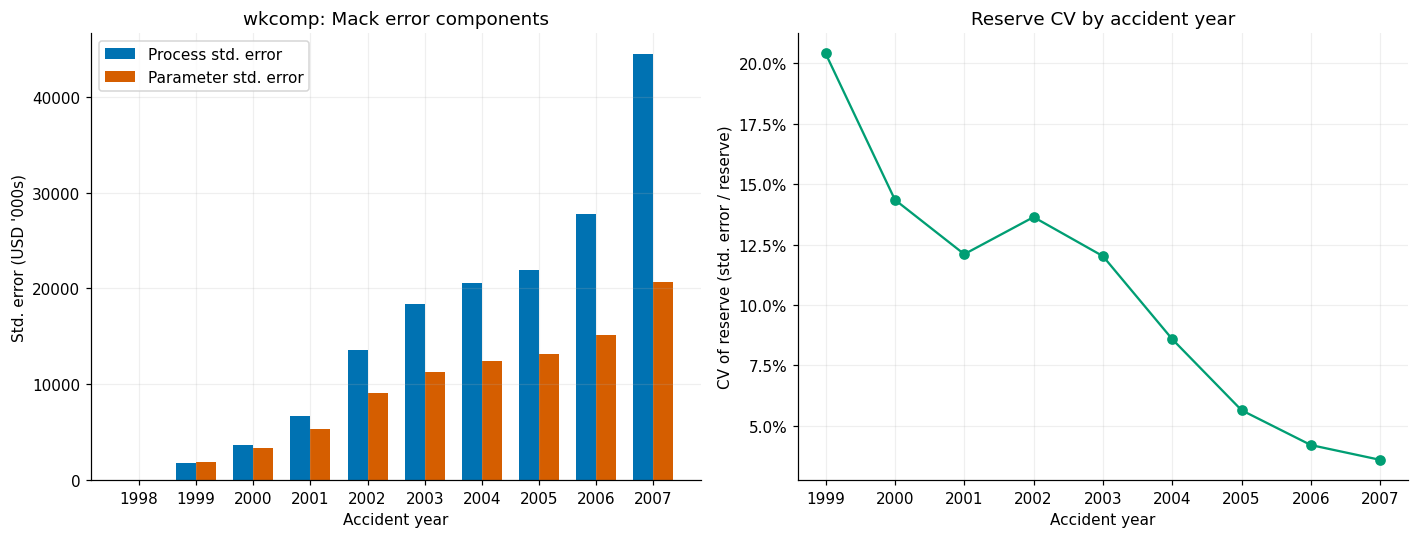

In [4]:
from matplotlib.ticker import PercentFormatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(decomp))
width = 0.35
axes[0].bar(x - width/2, decomp['process_std'], width, label='Process std. error', color='C0')
axes[0].bar(x + width/2, decomp['parameter_std'], width, label='Parameter std. error', color='C3')
axes[0].set_xticks(x); axes[0].set_xticklabels(decomp.index, rotation=0)
axes[0].set_ylabel("Std. error (USD '000s)"); axes[0].set_xlabel('Accident year')
axes[0].set_title(f'{PRIMARY_LINE}: Mack error components')
axes[0].legend()

axes[1].plot(decomp.index[1:], decomp['cv'].iloc[1:], 'o-', color='C2')
axes[1].set_xlabel('Accident year'); axes[1].set_ylabel('CV of reserve (std. error / reserve)')
axes[1].set_title('Reserve CV by accident year')
axes[1].set_xticks(decomp.index[1:]); axes[1].tick_params(axis='x', rotation=0)

axes[1].yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout(); plt.show()

Total reserve is 3,267,680.7 and standard error is 102,372.7: process error 65,021.1, parameter error 79,072.3 and CV 3.1%. A small reserve can have a high CV despite low absolute error, as in 1999 (20.4%).

## Lognormal quantiles

Mack estimates a mean and standard error. A moment-matched lognormal adds a distributional assumption, giving a total 99.5% quantile of 3,540,500.0.

In [5]:
quantiles = (0.75, 0.90, 0.95, 0.995)
pi_rows = []
for ay in decomp.index:
    if decomp.loc[ay, 'reserve'] <= 0:
        continue
    pi = rsv.lognormal_prediction_interval(decomp.loc[ay, 'reserve'], decomp.loc[ay, 'total_std_error'], quantiles)
    pi_rows.append(dict(AccidentYear=ay, reserve=decomp.loc[ay, 'reserve'], **{f'q{q}': pi[f'q{q}'] for q in quantiles}))
pi_table = pd.DataFrame(pi_rows).set_index('AccidentYear')

total_pi = rsv.lognormal_prediction_interval(mack_mine.total_reserve, mack_mine.total_std_error, quantiles)
print(f"Total reserve point estimate: {USD000(mack_mine.total_reserve)}")
print(f"Total reserve lognormal prediction interval: "
      f"q75={USD000(total_pi['q0.75'])}, q90={USD000(total_pi['q0.9'])}, "
      f"q95={USD000(total_pi['q0.95'])}, q99.5={USD000(total_pi['q0.995'])}")
money_display(pi_table, ['reserve', 'q0.75', 'q0.9', 'q0.95', 'q0.995'])

Total reserve point estimate: USD 3,267,680.7k
Total reserve lognormal prediction interval: q75=USD 3,335,810.8k, q90=USD 3,399,844.3k, q95=USD 3,438,752.3k, q99.5=USD 3,540,500.0k


,reserve,q0.75,q0.9,q0.95,q0.995
AccidentYear,,,,,
1999,"12,766.1","14,334.0","16,204.0","17,437.8","21,045.5"
2000,"34,542.1","37,648.6","41,057.7","43,243.8","49,391.9"
2001,"70,961.0","76,415.6","82,218.6","85,900.2","96,104.6"
2002,"119,786.2","130,066.9","141,238.5","148,378.1","168,364.5"
2003,"179,492.1","193,203.0","207,773.3","217,013.5","242,611.3"
2004,"280,098.7","295,674.7","311,460.0","321,307.1","347,985.4"
2005,"453,078.1","469,891.8","486,252.5","496,315.0","523,061.2"
2006,"751,706.6","772,622.6","792,573.7","804,759.1","836,846.9"
2007,"1,365,249.8","1,397,792.3","1,428,571.7","1,447,315.1","1,496,476.2"


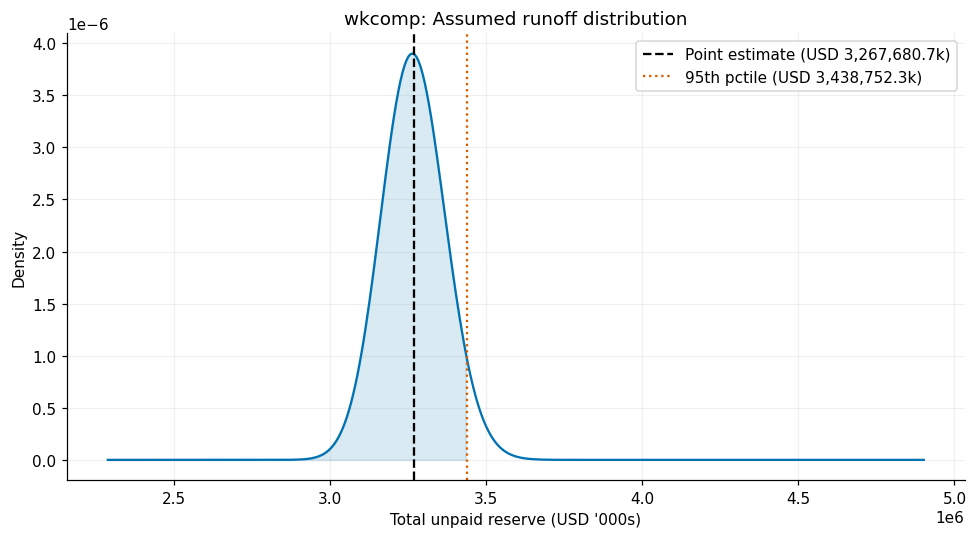

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
x_grid = np.linspace(mack_mine.total_reserve * 0.7, mack_mine.total_reserve * 1.5, 400)
pdf = stats.lognorm.pdf(x_grid, s=total_pi['sigma'], scale=np.exp(total_pi['mu']))
ax.plot(x_grid, pdf, color='C0')
ax.axvline(mack_mine.total_reserve, color='k', linestyle='--', label=f'Point estimate ({USD000(mack_mine.total_reserve)})')
ax.axvline(total_pi['q0.95'], color='C3', linestyle=':', label=f"95th pctile ({USD000(total_pi['q0.95'])})")
ax.fill_between(x_grid, 0, pdf, where=(x_grid <= total_pi['q0.95']), alpha=0.15, color='C0')
ax.set_xlabel("Total unpaid reserve (USD '000s)"); ax.set_ylabel('Density')
ax.set_title(f'{PRIMARY_LINE}: Assumed runoff distribution')
ax.legend()
plt.tight_layout(); plt.show()

## Runoff backtest

Refit at valuations 2007–2010 (the first ones where every factor can be estimated) and compare projected unpaid to what was actually paid through lag 10 for the same accident years. The newest year reaches lag 10 in 2016. The four tests overlap, so they are not four independent coverage trials.

In [7]:
backtest_rows = []
for val_year in [2007, 2008, 2009, 2010]:
    observed = rsv.mask_to_valuation(cum_paid_wkcomp_full, val_year)
    estimate = rsv.mack_chain_ladder(observed)
    actual_unpaid = float((cum_paid_wkcomp_full[10] - rsv.latest_diagonal(observed)).sum())
    interval = rsv.lognormal_prediction_interval(estimate.total_reserve, estimate.total_std_error, (.025,.975))
    backtest_rows.append(dict(valuation_year=val_year, final_calendar_year=2016,
        max_runoff_years=2016-val_year, projected_unpaid=estimate.total_reserve,
        actual_unpaid=actual_unpaid, lower95=interval['q0.025'], upper95=interval['q0.975'],
        covered=interval['q0.025'] <= actual_unpaid <= interval['q0.975']))
backtest_table = pd.DataFrame(backtest_rows).set_index('valuation_year')
display(backtest_table.round(1))

,final_calendar_year,max_runoff_years,projected_unpaid,actual_unpaid,lower95,upper95,covered
valuation_year,,,,,,,
2007,2016,9,"3,267,680.700","3,434,416.000","3,071,609.100","3,472,859.500",True
2008,2016,8,"2,062,363.600","2,126,739.000","1,930,467.200","2,200,810.000",True
2009,2016,7,"1,288,657.500","1,354,048.000","1,185,412.300","1,398,407.900",True
2010,2016,6,"825,201.500","853,636.000","753,627.900","901,682.700",True


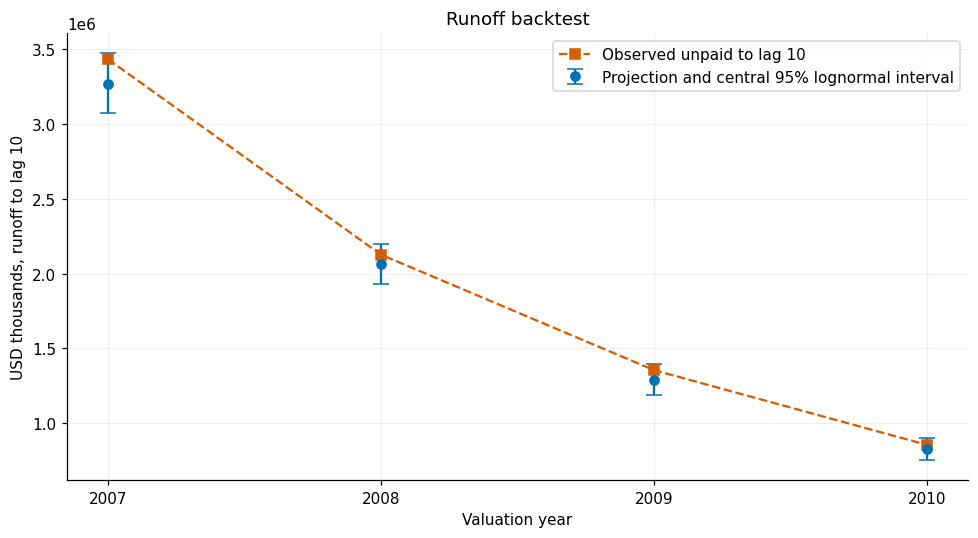

In [8]:
fig, ax = plt.subplots()
x = backtest_table.index.to_numpy()
ax.errorbar(x, backtest_table.projected_unpaid,
    yerr=[backtest_table.projected_unpaid-backtest_table.lower95, backtest_table.upper95-backtest_table.projected_unpaid],
    fmt='o', capsize=5, label='Projection and central 95% lognormal interval')
ax.plot(x, backtest_table.actual_unpaid, 's--', color='C3', label='Observed unpaid to lag 10')
ax.set_xlabel('Valuation year'); ax.set_ylabel('USD thousands, runoff to lag 10')
ax.set_xticks(x)
ax.set_title('Runoff backtest'); ax.legend(); plt.tight_layout(); plt.show()

Observed runoff lies within the central 95% interval at all four valuations. Four overlapping tests provide limited coverage evidence.

## All six lines

Repeat the Mack calculation for all CAS lines used in 11. Reserve-to-premium is total unpaid divided by the retained companies' AY2007 earned premium.

Medmal, othliab and prodliab contain 1, 1 and 2 negative paid increments. These warrant review of the development assumptions. Tail factor 1.0 excludes development beyond lag 10; its effect on reserve levels and CVs is not estimated.

In [9]:
LINES = ['ppauto', 'comauto', 'wkcomp', 'medmal', 'othliab', 'prodliab']
line_rows = []
for line in LINES:
    tri_l, rep_l = rsv.build_industry_triangle(DATA_DIR, line)
    cp_l = rsv.mask_to_valuation(tri_l['cum_paid'], VALUATION_YEAR)
    mack_l = rsv.mack_chain_ladder(cp_l)
    val_l = rsv.validate_triangle(cp_l)
    prem_latest = float(tri_l['earned_prem'].loc[VALUATION_YEAR])
    line_rows.append(dict(line=line, companies=rep_l.n_companies_full_square,
        reserve=float(mack_l.total_reserve), std_error=float(mack_l.total_std_error),
        cv=float(mack_l.total_cv), premium_latest_ay=prem_latest,
        reserve_to_premium=float(mack_l.total_reserve) / prem_latest,
        negative_paid_increments=int(val_l.n_negative_incremental)))
per_line_reserve = pd.DataFrame(line_rows).set_index('line')
np.testing.assert_allclose(per_line_reserve.loc['wkcomp', 'std_error'], mack_mine.total_std_error, rtol=1e-12)
display(per_line_reserve.round(4))

,companies,reserve,std_error,cv,premium_latest_ay,reserve_to_premium,negative_paid_increments
line,,,,,,,
ppauto,121,"18,723,967.601","378,494.013",0.020,"24,142,223.000",0.776,0
comauto,137,"2,064,726.906","75,432.450",0.036,"2,170,956.000",0.951,0
wkcomp,110,"3,267,680.669","102,372.700",0.031,"3,540,362.000",0.923,0
medmal,32,"847,715.911","217,921.948",0.257,"524,906.000",1.615,1
othliab,206,"2,906,068.213","247,105.906",0.085,"2,066,797.000",1.406,1
prodliab,59,"192,669.640","53,948.733",0.280,"158,200.000",1.218,2


## Runoff versus one-year view

These estimates describe unpaid-loss uncertainty through lag 10. A one-year claims-development model is not fitted, so the results do not establish one-year reserve risk. Notebook 10 uses separate assumed regulatory inputs; 11 uses the runoff approximation.

In [10]:
import json
reserve_risk_summary = {
    'line': PRIMARY_LINE, 'currency': "USD '000s", 'valuation_year': VALUATION_YEAR,
    'method': 'Mack (1993) distribution-free Chain-Ladder, sigma_interpolation=mack',
    'scope': 'ultimate runoff uncertainty, not the Solvency II one-year reserve risk',
    'total_reserve': float(mack_mine.total_reserve),
    'total_process_std': float(np.sqrt(mack_mine.total_process_variance)),
    'total_parameter_std': float(np.sqrt(mack_mine.total_parameter_variance)),
    'total_std_error': float(mack_mine.total_std_error),
    'total_cv': float(mack_mine.total_cv),
    'lognormal_pi': {k: float(v) for k, v in total_pi.items()},
    'backtest': backtest_rows,
    'per_line': per_line_reserve.reset_index().to_dict('records'),
    'per_line_note': 'Mack on paid triangles at valuation 2007, tail 1.0 at lag 10; medmal/othliab/prodliab are long-tail with negative increments, so their reserve and CV are likely understated.',
    'backtest_note': 'Overlapping retrospective fixed-cohort tests to development lag 10; not one-year risk.',
}
json.dump(reserve_risk_summary, open(result_path('reserve_risk_summary.json'), 'w'), indent=2)
print("Saved reserve_risk_summary.json for Notebook 11.")

Saved reserve_risk_summary.json for Notebook 11.


- Process and parameter errors include covariance from shared factors.
- Package agreement requires matching sigma extrapolation.
- Lognormal quantiles add an assumption beyond Mack.
- Backtests target runoff through lag 10 and overlap.
- Later development and the effect of negative increments remain unmodelled.

In [11]:
record_results('reserve_risk_summary.json')